# Actividad 6: MA2003B
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)

## Instrucciones:
- Active el kernel proveniente de `Anaconda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Prohibido usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

#  1. Regresión Logística

Usamos regresión logística cuando queremos clasificar datos que pertenecen a un grupo o a otro.

The datasets we will be working with for this example are:
- `/path/to/your/data/logistic_regression_training.npy`
- `/path/to/your/data/logistic_regression_validation.npy`
- `/path/to/your/data/logistic_regression_testing.npy`

We have specifically added in a validation set, which will be used to check if the models we make are being overfit to the training set. It is important that the *test* data is not used in optimizing model selections.

## 1.1. Cargar los datos
Load the datasets. These numpy arrays have a shape of (number of events, 3). The first two columns of the 3 are $x_1$ and $x_2$. The last columns is a number 0 or 1, which indicates if the event was a background or signal, respectively.

**Exercise:** Load the data and seperate out the data columns from the label. (Hint: use the slicing feature of numpy)



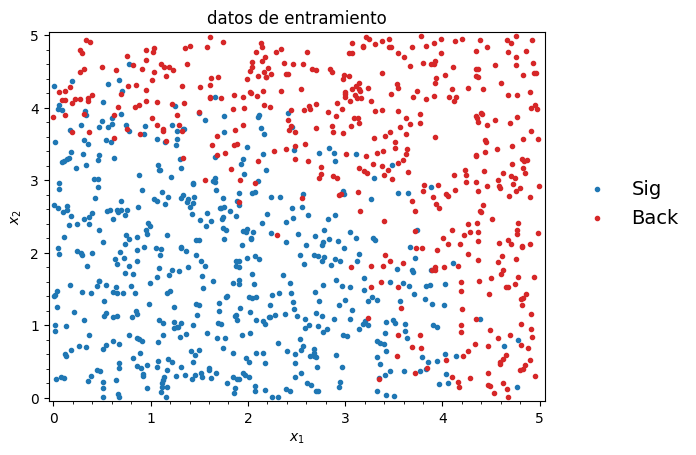

In [81]:
training = np.load('../Data/logistic_regression_training.npy')
X_Train = training[:, :2]
Y_Train = training[:, 2].reshape(-1, 1)  # makes it a vector

validation = np.load('../Data/logistic_regression_validation.npy')
X_Val = validation[:, :2]
Y_Val = validation[:, 2].reshape(-1, 1)  # makes it a vector

testing = np.load('../Data/logistic_regression_training.npy')
X_Test = testing[:, :2]
Y_Test = testing[:, 2].reshape(-1, 1)  # makes it a vector

# graficar datos
plt.scatter(X_Train[np.ravel(Y_Train==1), 0], X_Train[np.ravel(Y_Train==1), 1], color='C0', s=9, label='Sig')
plt.scatter(X_Train[np.ravel(Y_Train==0), 0], X_Train[np.ravel(Y_Train==0), 1], color='C3', s=9, label='Back')
plt.xlim(-0.05, 5.05)
plt.ylim(-0.05, 5.05)
plt.minorticks_on()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc=(1.05, 0.45), frameon=False, fontsize=14)
plt.title('datos de entramiento')
plt.show()

Our goal is now to find a model which will predict whether a point $(x_1, x_2)$ in parameter space comes from either the Signal set or the Background set. As a first approximation, the boundary between the two is approximately linear. We will use this our first model.

## 1.2. Sigmoid
In order to interpret our results, we will first need to modify our model such that the output is always between 0 and 1. Such a function is usually called a sigmoid function. We will use the most common definition as
$$
\sigma(z) \equiv \frac{1}{1+e^{-z}}
$$

**Exercise:** Program a function for the sigmoid definition. Then plot $\sigma(z)$ for $z\in [-5, 5]$. Hint, use [this](https://docs.scipy.org/doc/numpy/reference/generated/numpy.exp.html).

In [82]:
def sigmoid(z):
    '''
    Computes the sigmoid of z
    
    Arguments:
    z -- A scalar or numpy array of any size
    
    Return:
    s -- sigmoid(z)
    '''
    
    ### Start code here ### (about 1 line of code)
    s = 1/(1+np.exp(-z))
    ### End code here ###
    
    return s

Test the implementation

In [83]:
sigmoid(np.array([0, 1, 2]))

array([0.5       , 0.73105858, 0.88079708])

**Expected Output:**
<table>
  <tr>
     <td> sigmoid([0,1,2])</td>
    <td>array([0.5       , 0.73105858, 0.88079708])</td> 
  </tr>
</table>

Graficar la funcion

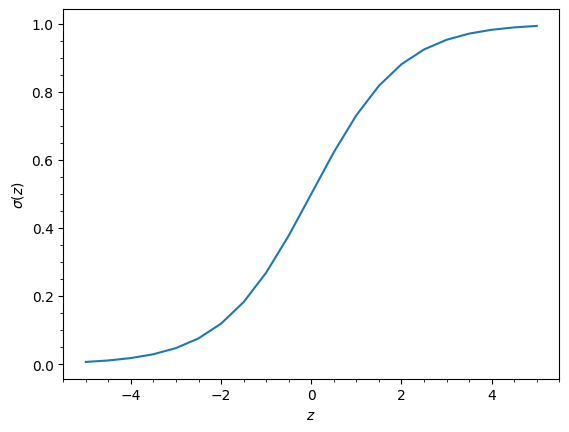

In [84]:
z = np.linspace(-5, 5, 21)
plt.plot(z, sigmoid(z))
plt.minorticks_on()
plt.xlabel('$z$')
plt.ylabel(r'$\sigma(z)$')
plt.show()

With this simple modification, we can now use a very similar model to what we had before. The first part of our linear model will be to take
\begin{equation}
z^i = w_1~x_1^i + w_2~x_2^i + b~,
\end{equation}
where supsript $i$ refers to the specific data point and the subscript refers to the particular dimension of the data. This should look very similar to our linear model before, where $b$ is again the bias, but now we have two "slopes" which we mark as $w_j$ instead of $m$. From now on, these will be called "weights". In building up to large dimensional data, we don't want to write out all of this multiplication by hand. Instead we will make a vector $W = (w_1, w_2, \cdots)$ and use the dot product.

In our optimization, we will learn the values of $w_1$, $w_2$, and $b$ which minimizes the loss. Note that we want these to yield **large positive** values of $z$ for events that are signal-like (lower left corner) and **large negative** values for the background-like (upper right). Then, when we feed these through the sigmoid function, they will be mapped to 0 and 1.

Feeding the results through the sigmoid is called the *activation*. The sigmoid is not the only function that can be used for this. 

## 1.3. Loss function
It is possible to use the mean squared error for classification, however, minimizing this does not lead to the best classification. 

To accomplish best classification in logistic regression, we use the **Binary Cross Entropy**. For a very nice lecture on how this can be derived from a probability standpoint, see [Lecture 2 of Gilles Louppe's class](https://github.com/glouppe/info8010-deep-learning).

The binary cross entropy is defined as
$$
L^{\rm{BCE}} = -\frac{1}{N} \sum_i^N y^i \log f(\mathbf{x}^i) + \big(1-y^i\big) \log\big(1-f(\mathbf{x}^i) \big)
$$

where $y^i$ is again the true label, and $f(\mathbf{x}^i)$ is the bold and the vector denotes that $\mathbf{x}$ has multiple dimensions.

Let's examine why BCE works and addresses the problems we had with MSE. If the event is from the class $y=1$, then the first term contributes and the second term is identically 0. If the overall prediction is close to 1, the loss asymptotes to 0. So the more confident the model is, the lower the loss. Conversely, the more negative $z$ is, the closer to 0 is the prediction. When we take the $\log$ of this, the loss blows up (note the overall negative sign in the front of the sum). The story is similar for events coming from $y=0$. Now the first term is identically 0, and the second term contributes. Predictions close to 0 now result in small losses while perdictions close to 1 yield very large losses. While this is not a proof, it at least gives some intuition for why this loss function is used for binary classification problems.

**Exercise:** Implement the Binary Cross Entropy loss function.

In [85]:
def BCE(y_true, y_pred):
    '''
    Computes the binary cross entropy
    
    Arguments:
    y_true -- 1 dimensional numpy array with the true labels. Should all be either 0 or 1
    y_pred -- 1 dimensional numpy array containing predictions. Should be continuous between 0 and 1
    
    Return:
    bce -- scalar value
    '''
    
    # Compute the BCE and do not use a loop
    ### Start code here ### (about 1 line of code)
    bce = (-1/len(y_true))*np.sum(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))
    ### End code here ###
    
    return bce

Probar la implementación

In [86]:
BCE(np.array([0, 0, 1, 1]), np.array([0.01, 0.99, 0.01, 0.99]))

np.float64(2.307610260920796)

**Expected Output:**
<table>
  <tr>
    <td> BCE([0, 0, 1, 1]), [0.01, 0.99, 0.01, 0.99]) </td>
    <td> 2.307610260920796 </td> 
  </tr>
</table>


## 1.4. Gradients
We are now almost ready to make our first classiciation model. The last things needed for the optimization are the gradients. You should check the following results. I use $z$ just to help with the chain rule.

$$
\frac{\partial}{\partial z} L^{\rm{BCE}}\big(y_{\rm{true}}, y_{\rm{pred}}(z) \big)
 = \frac{1}{N}\sum_i^N \left(\frac{1-y_{\rm{true}}}{1-y_{\rm{pred}}(z)} - \frac{y_{\rm{true}}}{y_{\rm{pred}}(z)} \right) \frac{\partial y_{\rm{pred}}(z)}{\partial z}
$$


We use $y_{\rm{pred}}\big(z(x)\big) = \sigma\big(z(x)\big)$, 
$$
\begin{aligned}
\frac{\partial \sigma\big(z(x)\big)}{\partial x} &= \frac{e^{-z(x)}}{\big(1+e^{-z(x)} \big)^2} \frac{\partial z(x)}{\partial x} \\
&= \sigma\big(z(x) \big) \Big(1-\sigma\big(z(x) \big) \Big) \frac{\partial z(x)}{\partial x}
\end{aligned}
$$
where $x$ is just another dummy variable, and *not* the data.

Finally, we use $z^i = W\cdot \mathbf{x}^i + b$, giving:
$$
\frac{\partial z(w,b)}{\partial w_j} = x_j^i
$$
and
$$
\frac{\partial z(w,b)}{\partial b} = 1
$$

It will be beneficial to program in a function for the derivative of the sigmoid.

**Exercise:** Implement the sigmoid_derivative to compute the derivative with respect to the input.

In [87]:
def sigmoid_derivative(z):
    '''
    Compute the gradient of the sigmoid function with respect to its input z.
    It can be useful to store this into a variable later
    
    Arguments:
    z -- A scalar or numpy array
    
    Returns:
    ds -- The computed gradient
    '''
    
    ### Start code here ### (around a few lines of code)
    s = sigmoid(z)
    ds = s*(1-s)
    ### End code here ####
    
    return ds

Probar implementación

In [88]:
sigmoid_derivative(np.array([1,2,3]))

array([0.19661193, 0.10499359, 0.04517666])

**Expected Output**: 

<table>
    <tr> 
        <td> sigmoid_derivative([1,2,3])</td> 
        <td> [ 0.19661193  0.10499359  0.04517666] </td> 
    </tr>
</table> 

## 1.5. Weights and matrix multiplication
Let's write a function that inializes zeros and checks the dimensions, this will be a function of the number of dimensions so that when we go to larger datasets we don't have to do it by hand

**Exercise:** Implement a function to output a vector of zeros for the weights and a single 0 for the bias. Hint: look up [numpy's zeros function](https://docs.scipy.org/doc/numpy/reference/generated/numpy.zeros.html?highlight=zeros#numpy.zeros)

In [89]:
def initialize_zeros(dim):
    '''
    This function creates a vecor of zeros with shape (dim, 1) for W.
    It also inializes b to 0
    
    Argument:
    dim -- interger, the size of the w vector
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar for the bias
    '''
    
    ### Start code here ###
    w = np.zeros((dim,1))
    b = 0.0
    ### end code here
    
    assert(w.shape == (dim, 1))
    assert(isinstance(b, float))
    
    return w, b

Probar la implementación

In [90]:
dim = 2
w, b = initialize_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]]
b = 0.0


**Expected Output**: 


<table style="width:15%">
    <tr>
        <td>  w  </td>
        <td> [[ 0.]
 [ 0.]] </td>
    </tr>
    <tr>
        <td>  b </td>
        <td> 0 </td>
    </tr>
</table>

With this setup, we now have that the shape of $W$ is (2, 1). Each data vector for $X$ is a shape (1, 2) as well. The overall shape of the data is (N, 2). We want to get out the dot product over each row, so the output should be of the shape (N, 1)

\begin{equation}
Z = X\cdot W + b
\end{equation}

In some cases (namely doing images) the input data may have yet and extra dimension in the shape (the RGB colors for each pixel). Care needs to be taken in doing the matrix multiplication correctly.

**Exercise:** Check that the matrix multiplication works as expected. Note the difference in numpy between `*` and `.dot()`.

In [91]:
# Use *
# escriba su codigo aqui
Z= np.array([1,2,3])*np.array([1,2,3])
print(Z)

# Use np.dot()
# escriba su codigo aqui
Z= np.dot(np.array([1,2,3]),np.array([1,2,3]))
print(Z)


[1 4 9]
14


## 1.6. Forward and backward propagation
Now that the parameters have been initalized, we can do the forward and backward steps for learning the parameters.

**Exercise:** Implement a function `propagate()` that computes the loss function and gradient.

**Hints:**

Forward propagation:
* You get $X$
* Compute $A = \sigma\big(X\cdot W +b\big) = \big(a_{1}, a_{2},\cdots,a_{N}\big)$
* Calculate the loss function $L = -\frac{1}{N} \sum_{i=1}^N y_i \log a_i + \big(1-y_i\big) \log\big(1-a_i\big)$

It will be usefull to fill in the rest of the chain rule and simplify to get
\begin{equation}
\frac{\partial L}{\partial w^j} = \frac{1}{N} \sum_{i=1}^N (a_i - y_i) * x_i^j 
\end{equation}
and
\begin{equation}
\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N (a_i - y_i)~.
\end{equation}
Again, we want to not use any explicit for loops, so be careful with the shapes when multiplying arrays.

In [92]:
def propagate(w, b, X, Y):
    '''
    Implement the loss function and its gradient for the propagation above
    
    Arguments:
    w -- weights, a numpy array of size (dim(x[0]), 1)
    b -- bias, a scalar
    X -- data with shape (number of datapoints, dimensionality of the data)
    Y -- true label, vector of 0 or 1
    
    Returns:
    loss -- BCE which is the negative log-likelihhood (loss and loss are used interchangeably)
    dw -- gradient of the loss with respect to w, needs to be the same shape as w
    db -- gradient of the loss with respect to b, needs to be the same shape as b
    
    Tips:
    Write the code step by step and use np.log() and np.dot().
    Print shapes if you need to get the dot products correct.
    '''
    N = X.shape[0]  # number of data points
    
    # Forward propagation (from X to loss)
    # Do not use a loop
    ### Start code here ### (around 2 lines of code)
    A = sigmoid(np.dot(X,w)+b)
    loss =  BCE(Y,A)
    ### End code here ###
    
    # Backward propogration (to find the gradient)
    ### Start code here ### (around 2 lines of code)
    # Do not use a loop
    dw = np.dot(X.T,(A-Y))/N # [Hint: use X.T y (A-Y)]
    db = np.mean((A-Y))
    ### END CODE HERE ###

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    loss = np.squeeze(loss)
    assert(loss.shape == ())
    
    grads = {"dw": dw,
             "db": db}
    
    return grads, loss

Probar la implementación

In [93]:
w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]).T, np.array([[1,0,1]])
grads, loss = propagate(w, b, X, Y.reshape(-1, 1))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("loss = " + str(loss))

dw = [[0.99845601]
 [2.39507239]]
db = 0.001455578136784208
loss = 5.801545319394553


## 1.7. Optimization
Now that we have initialized our parameters and can compute the loss and the gradient, we can find the minimum of the loss function using gradient descent.

**Exercise:** Write the optimization function. The goal is to learn $w$ and $b$ minimizing $L^{\rm{BCE}}$. As before, for a parameter $\theta$, the update rule is $\theta = \theta - \alpha~ d\theta$, where $\alpha$ is the learning rate.

In [94]:
def optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_loss=False, X_val=None, Y_val=None):
    '''
    This function minimizes the BCE loss function by running gradient descent
    
    Arguments:
    w -- weights, a numpy array of size (dim(data), 1)
    b -- bias, a scalar
    X_train -- data of shape (number of samples, dim(data))
    Y_train -- true label of shape (number of samples, 1)
    num_iterations -- number of updates using the gradient, an integer
    learning_rate -- a float which affects the update size
    print_loss -- boolean to print the loss ever 100 steps. Default is False
    X_val -- data of shape (number of samples, dim(data)). Default is None
    Y_val -- true label of shape (number of samples, 1). Default is None
    
    If X_val and Y_val are not None, the loss is computed on the validation data
    
    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the loss function
    losss -- list of all the losss computed during the optimization, this will be used to plot the learning curve.
    '''
    
    losss = {'train': [],
             'validation': []
            }
    
    for i in range(num_iterations):
        
        # loss and gradient calculation (around 1-4 lines of code)
        ### Start code here ###
        grads, loss = propagate(w,b,X_train,Y_train)
        ### end code here
        
        # Retrieve derivatives from grads
        ### Start code here ###
        dw = grads['dw']
        db = grads['db']
        ### End code here ###
        
        # Calculate the loss on the validation data
        if (X_val is not None) and (Y_val is not None):
            ### Start code here
            # Do not use a loop
            A_val = sigmoid(np.dot(X_Val,w)+b)
            loss_val = BCE(Y_Val,A_val)
            ### End code here 
            
            losss['validation'].append(loss_val)
            
        # update rule (≈ 2 lines of code)
        ### START CODE HERE ###
        w = w - learning_rate*dw
        b = b -learning_rate*db
        ### END CODE HERE ###
        
        # Record the losss
        losss['train'].append(loss)
        
        # Print the loss every 100 training iterations
        if print_loss and i % 100 == 0:
            print ("loss after iteration %i: %f" %(i, loss))
    
    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, losss
        

Probar la implementación

In [95]:
params, grads, losss = optimize(w, b, X, Y.reshape(-1, 1), num_iterations= 100, learning_rate = 0.009, print_loss = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

w = [[0.19033591]
 [0.12259159]]
b = 1.9253598300845747
dw = [[0.67752042]
 [1.41625495]]
db = 0.21919450454067657


**Expected Output**: 

<table style="width:40%">
    <tr>
       <td> w </td>
       <td>[[ 0.19033591]
 [ 0.12259159]] </td>
    </tr>
    <tr>
       <td> b </td>
       <td> 1.92535983008 </td>
    </tr>
    <tr>
       <td> dw </td>
       <td> [[ 0.67752042]
 [ 1.41625495]] </td>
    </tr>
    <tr>
       <td> db </td>
       <td> 0.219194504541 </td>
    </tr>

</table>

If those worked, we are now ready to classify our example data.

**Exercise:** Train a logistic regression model on the example. Use around 10000 iterations and pick an appropriate learning rate. We want the performance to be saturating by the end.

In [96]:
# Initialize w and b
w, b = initialize_zeros(2)

# Optimize
params, grads, losss = optimize(w,b,X_Train,Y_Train,10000,0.01,False,X_Val,Y_Val)

Plot the loss as a function of epoch.

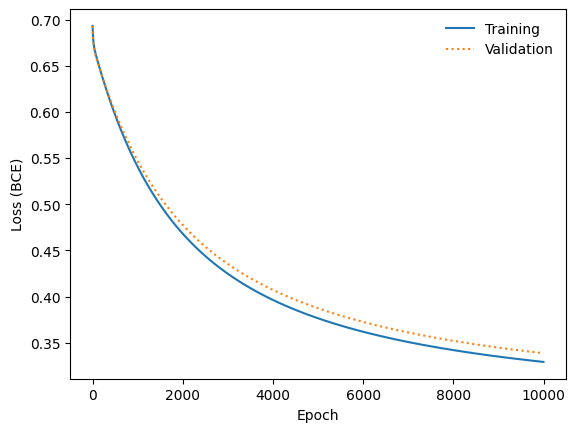

In [97]:
plt.plot(losss['train'], label='Training')
plt.plot(losss['validation'], label='Validation', ls=':')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.legend(loc='upper right', frameon=False)
plt.show()

Our training and validation losses are nearly identical, so we are not overfitting. This is expected because we are using such an easy model. Now lets plot the decision boundary found by the model. There will be a few lines of matplotlib and numpy in order to plot isocurves of constant model prediction.

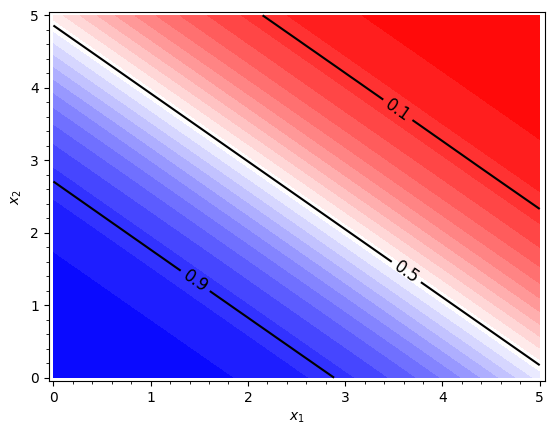

In [98]:
x_space = np.linspace(0, 5, 25)
y_space = np.linspace(0, 5, 25)
X, Y = np.meshgrid(x_space, y_space)
Z = sigmoid(X * params['w'][0] + Y * params['w'][1] + params['b'])  # the 1 - sigmoid just gets the numbering right for the color map below

plt.contourf(X, Y, 1-Z, 25, cmap='bwr')
CS = plt.contour(X, Y, Z, [0.1, 0.5, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim(-0.05, 5.05)
plt.ylim(-0.05, 5.05)
plt.minorticks_on()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

Our linear model draws straight lines through the space. The nominal decision boundard is when the output it $\ge 0.5$, in which case it is more likely to be signal than background. How does this match up with out test data?

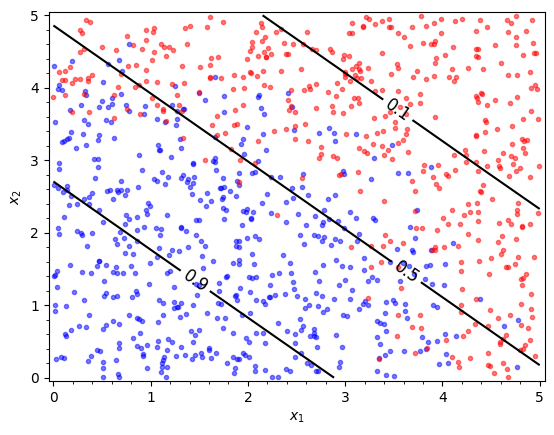

In [99]:
plt.scatter(X_Test[Y_Test.ravel()==1, 0], X_Test[Y_Test.ravel()==1, 1], color='b', s=9, alpha=0.5)
plt.scatter(X_Test[Y_Test.ravel()==0, 0], X_Test[Y_Test.ravel()==0, 1], color='r', s=9, alpha=0.5)
CS = plt.contour(X, Y, Z, [0.1, 0.5, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim(-0.05, 5.05)
plt.ylim(-0.05, 5.05)
plt.minorticks_on()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

## 1.8. Datos con fronteras no lineales

Ejercicio: clasifique los datos proporcionados por el profesor

In [100]:
from sklearn.model_selection import train_test_split

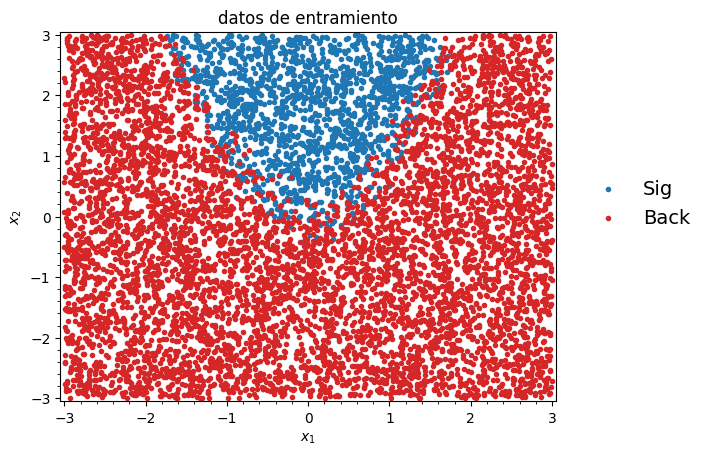

In [101]:
training,testing = train_test_split(np.load('../Data/nonlinear_logistic_1.npy'),test_size=0.2,random_state=42)

X_Train = training[:, :2]
Y_Train = training[:, 2].reshape(-1, 1)  # makes it a vector

X_Test = testing[:, :2]
Y_Test = testing[:, 2].reshape(-1, 1)  # makes it a vector

# graficar datos
plt.scatter(X_Train[np.ravel(Y_Train==1), 0], X_Train[np.ravel(Y_Train==1), 1], color='C0', s=9, label='Sig')
plt.scatter(X_Train[np.ravel(Y_Train==0), 0], X_Train[np.ravel(Y_Train==0), 1], color='C3', s=9, label='Back')
plt.xlim(-3.05, 3.05)
plt.ylim(-3.05, 3.05)
plt.minorticks_on()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc=(1.05, 0.45), frameon=False, fontsize=14)
plt.title('datos de entramiento')
plt.show()

In [102]:
def initialize_zeros(dim):
    '''
    This function creates a vecor of zeros with shape (dim, 1) for W.
    It also inializes b to 0
    
    Argument:
    dim -- interger, the size of the w vector
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar for the bias
    '''
    
    ### Start code here ###
    w1 = np.zeros((dim,1))
    w2 = np.zeros((dim,1))
    b = 0.0
    ### end code here
    
    assert(w.shape == (dim, 1))
    assert(isinstance(b, float))
    
    return w1, w2, b

In [103]:
def propagate(w1, w2, b, X, Y):
    '''
    Implement the loss function and its gradient for the propagation above
    
    Arguments:
    w -- weights, a numpy array of size (dim(x[0]), 1)
    b -- bias, a scalar
    X -- data with shape (number of datapoints, dimensionality of the data)
    Y -- true label, vector of 0 or 1
    
    Returns:
    loss -- BCE which is the negative log-likelihhood (loss and loss are used interchangeably)
    dw1 -- gradient of the loss with respect to w, needs to be the same shape as w
    dw2 -- gradient o the loss with respect to w, needs to bbe same shape as w
    db -- gradient of the loss with respect to b, needs to be the same shape as b
    
    Tips:
    Write the code step by step and use np.log() and np.dot().
    Print shapes if you need to get the dot products correct.
    '''
    N = X.shape[0]  # number of data points
    
    # Forward propagation (from X to loss)
    # Do not use a loop
    ### Start code here ### (around 2 lines of code)
    A = sigmoid(np.dot(X**2,w1) + np.dot(X,w2)+b)
    loss =  BCE(Y,A)
    ### End code here ###
    
    # Backward propogration (to find the gradient)
    ### Start code here ### (around 2 lines of code)
    # Do not use a loop
    dw1 = np.dot((X.T**2),(A-Y))/N # [Hint: use X.T y (A-Y)]
    dw2 = np.dot((X.T),(A-Y))/N
    db = np.mean((A-Y))
    ### END CODE HERE ###

    assert(dw1.shape == w1.shape)
    assert(db.dtype == float)
    loss = np.squeeze(loss)
    assert(loss.shape == ())
    
    grads = {"dw1": dw1,
             'dw2': dw2,
             "db": db}
    
    return grads, loss

In [104]:
def optimize(w1,w2, b, X_train, Y_train, num_iterations, learning_rate, print_loss=False, X_val=None, Y_val=None):
    '''
    This function minimizes the BCE loss function by running gradient descent
    
    Arguments:
    w -- weights, a numpy array of size (dim(data), 1)
    b -- bias, a scalar
    X_train -- data of shape (number of samples, dim(data))
    Y_train -- true label of shape (number of samples, 1)
    num_iterations -- number of updates using the gradient, an integer
    learning_rate -- a float which affects the update size
    print_loss -- boolean to print the loss ever 100 steps. Default is False
    X_val -- data of shape (number of samples, dim(data)). Default is None
    Y_val -- true label of shape (number of samples, 1). Default is None
    
    If X_val and Y_val are not None, the loss is computed on the validation data
    
    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the loss function
    losss -- list of all the losss computed during the optimization, this will be used to plot the learning curve.
    '''
    
    losss = {'train': [],
             'validation': []
            }
    
    for i in range(num_iterations):
        
        # loss and gradient calculation (around 1-4 lines of code)
        ### Start code here ###
        grads, loss = propagate(w1,w2,b,X_train,Y_train)
        ### end code here
        
        # Retrieve derivatives from grads
        ### Start code here ###
        dw1 = grads['dw1']
        dw2 = grads['dw2']
        db = grads['db']
        ### End code here ###
        
        # Calculate the loss on the validation data
        if (X_val is not None) and (Y_val is not None):
            ### Start code here
            # Do not use a loop
            A_val = sigmoid(np.dot(X**2,w1) + np.dot(X_Val,w2)+b)
            loss_val = BCE(Y_Val,A_val)
            ### End code here 
            
            losss['validation'].append(loss_val)
            
        # update rule (≈ 2 lines of code)
        ### START CODE HERE ###
        w1 = w1 - learning_rate*dw1
        w2 = w2 - learning_rate*dw2
        b = b -learning_rate*db
        ### END CODE HERE ###
        
        # Record the losss
        losss['train'].append(loss)
        
        # Print the loss every 100 training iterations
        if print_loss and i % 100 == 0:
            print ("loss after iteration %i: %f" %(i, loss))
    
    params = {"w1": w1,
              'w2':w2,
              "b": b}
    
    grads = {"dw1": dw1,
             'dw2':dw2,
             "db": db}
    
    return params, grads, losss
        

In [105]:
# Initialize w and b
w1, w2, b = initialize_zeros(2)

# Optimize
params, grads, losss = optimize(w1,w2,b,X_Train,Y_Train,10000,0.01)

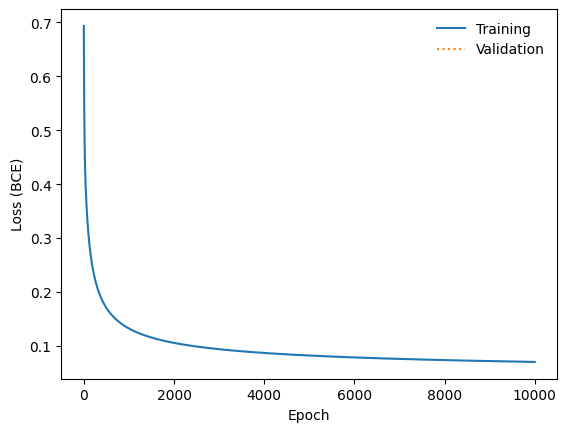

In [106]:
plt.plot(losss['train'], label='Training')
plt.plot(losss['validation'], label='Validation', ls=':')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.legend(loc='upper right', frameon=False)
plt.show()

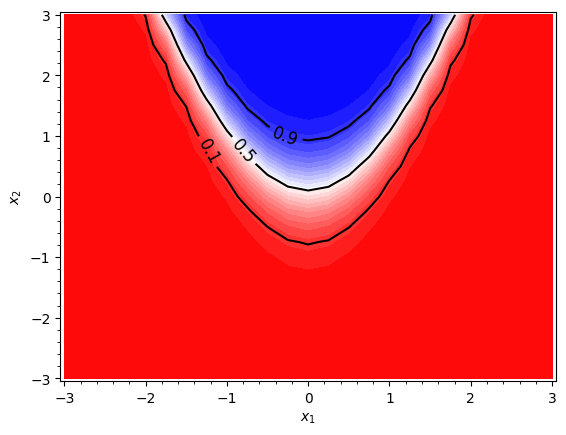

In [107]:
x_space = np.linspace(-3, 3, 25)
y_space = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x_space, y_space)
Z = sigmoid( X**2 * params['w1'][0] + Y**2 * params['w1'][1] + X * params['w2'][0] + Y * params['w2'][1] + params['b'])  # the 1 - sigmoid just gets the numbering right for the color map below

plt.contourf(X, Y, 1-Z, 25, cmap='bwr')
CS = plt.contour(X, Y, Z, [0.1, 0.5, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim(-3.05, 3.05)
plt.ylim(-3.05, 3.05)
plt.minorticks_on()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

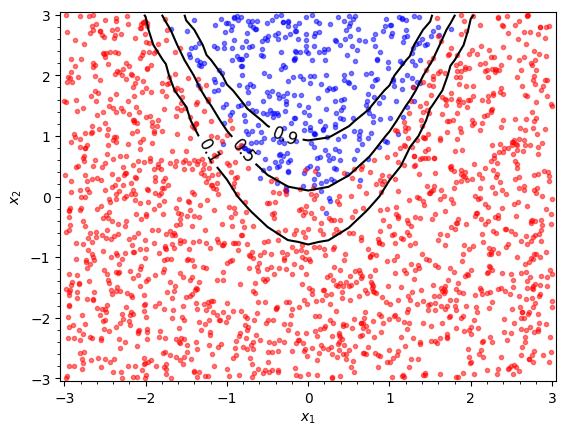

In [109]:
plt.scatter(X_Test[Y_Test.ravel()==1, 0], X_Test[Y_Test.ravel()==1, 1], color='b', s=9, alpha=0.5)
plt.scatter(X_Test[Y_Test.ravel()==0, 0], X_Test[Y_Test.ravel()==0, 1], color='r', s=9, alpha=0.5)
CS = plt.contour(X, Y, Z, [0.1, 0.5, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim(-3.05, 3.05)
plt.ylim(-3.05, 3.05)
plt.minorticks_on()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()